# Conditional generation

In [1]:
from pathlib import Path
import sys
import yaml
import random

import matplotlib.pyplot as plt
import numpy as np
import torch

ROOT = Path.cwd()
while not (ROOT / 'src').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.config import Config
from src.model.flow_matching_model.samples import Samples
from src.utils.cyclic_detector import CyclicDetector
from src.utils.drw import DRWManager
from src.utils.noise_models import AR1NoiseModel
import src.model.flow_matching_model as flow_matching

NOTEBOOK_DIR = ROOT / 'figures' / 'paper' / 'conditional generation'
FIGURE_PATH = NOTEBOOK_DIR / 'conditional generation.png'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
SEED = 11

torch.manual_seed(SEED)
np.random.seed(SEED)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.dpi': 140,
    'savefig.dpi': 300,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.frameon': False,
})

def seed_all(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


/nfs/scistore20/bronsgrp/nsellam/miniforge3/envs/ml/lib/python3.11/site-packages/transformers/utils/generic.py:441: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  _torch_pytree._register_pytree_node(


In [2]:
def load_config(output_name: str) -> Config:
    with open(ROOT / 'outputs' / output_name / 'config.yaml', 'r') as handle:
        return Config(**yaml.safe_load(handle))


def load_flow_model(output_name: str, checkpoint_name: str):
    config = load_config(output_name)
    wrapper_cls = getattr(flow_matching, config.lightning_wrapper)
    checkpoint_path = ROOT / 'outputs' / output_name / checkpoint_name
    model = wrapper_cls.load_from_checkpoint(checkpoint_path, config=config, map_location=DEVICE)
    return model.eval().to(DEVICE)


class PaperFlowNoiseModel:
    def __init__(self, model, num_steps: int = 40):
        self.model = model
        self.num_steps = int(num_steps)

    @torch.no_grad()
    def generates_curves_like(self, reference_curves, num_curves):
        curves = torch.as_tensor(reference_curves, dtype=torch.float32, device=self.model.device)
        if curves.ndim == 2:
            curves = curves[:, None, :]
        domain_curves = self.model.to_domain(Samples(curves, domain='time', t=1)).curves
        condition = self.model.encode(domain_curves)
        condition = condition[:, None].repeat(1, num_curves, 1).flatten(0, 1)
        generated = self.model.domain_sample(condition.shape[0], condition=condition, num_steps=self.num_steps)
        time_curves = self.model.to_domain(generated, 'time').curves[:, 0]
        return time_curves.reshape(curves.shape[0], num_curves, -1).cpu()


In [3]:
SIGMA = 0.2
consistency_model_folder = "gaussian prior - conditional generation - big model"
no_consistency_model_folder = "gaussian prior - conditional generation - no consistency - big model"
no_contrastive_model_folder = "gaussian prior - conditional generation - no contrastive - big model"
checkpoint = "step=step=007500.ckpt"
consistency_model = load_flow_model(consistency_model_folder, checkpoint)
consistency_model = PaperFlowNoiseModel(consistency_model)
no_consistency_model = load_flow_model(no_consistency_model_folder, checkpoint)
no_contrastive_model_folder = load_flow_model(no_contrastive_model_folder, checkpoint)
no_consistency_model = PaperFlowNoiseModel(no_consistency_model)
no_contrastive_model = PaperFlowNoiseModel(no_contrastive_model_folder)

seed_all(SEED)
drw_manager = DRWManager(sigma=SIGMA, observation_noise=0.0)


/nfs/scistore20/bronsgrp/nsellam/miniforge3/envs/ml/lib/python3.11/site-packages/pytorch_lightning/utilities/migration/utils.py:49: PossibleUserWarning: The loaded checkpoint was produced with Lightning v2.5.5, which is newer than your current Lightning version: v1.9.5
  rank_zero_warn(


In [4]:
coeffs = list(np.arange(0.2,1,0.1))
num_curves = 500
results_dict = {}
for coeff in coeffs:
    reference_curves = drw_manager.simulate_from_params(torch.tensor([coeff]).repeat(num_curves))
    no_consistency_model_curves = no_consistency_model.generates_curves_like(reference_curves, 1).squeeze()
    no_contrastive_model_curves = no_contrastive_model.generates_curves_like(reference_curves, 1).squeeze()
    consistency_model_curves = consistency_model.generates_curves_like(reference_curves, 1).squeeze()
    no_consistency_coeffs = drw_manager.estimate_parameters(no_consistency_model_curves, 1)
    no_contrastive_coeffs = drw_manager.estimate_parameters(no_contrastive_model_curves, 1)
    consistency_coeffs = drw_manager.estimate_parameters(consistency_model_curves, 1)
    reference_coeffs = drw_manager.estimate_parameters(reference_curves, 1)
    results_dict[coeff] = {
     "no_consistency_coeffs": no_consistency_coeffs,
     "no_contrastive_coeffs": no_contrastive_coeffs,
     "consistency_coeffs": consistency_coeffs,
     "reference_coeffs": reference_coeffs
    }


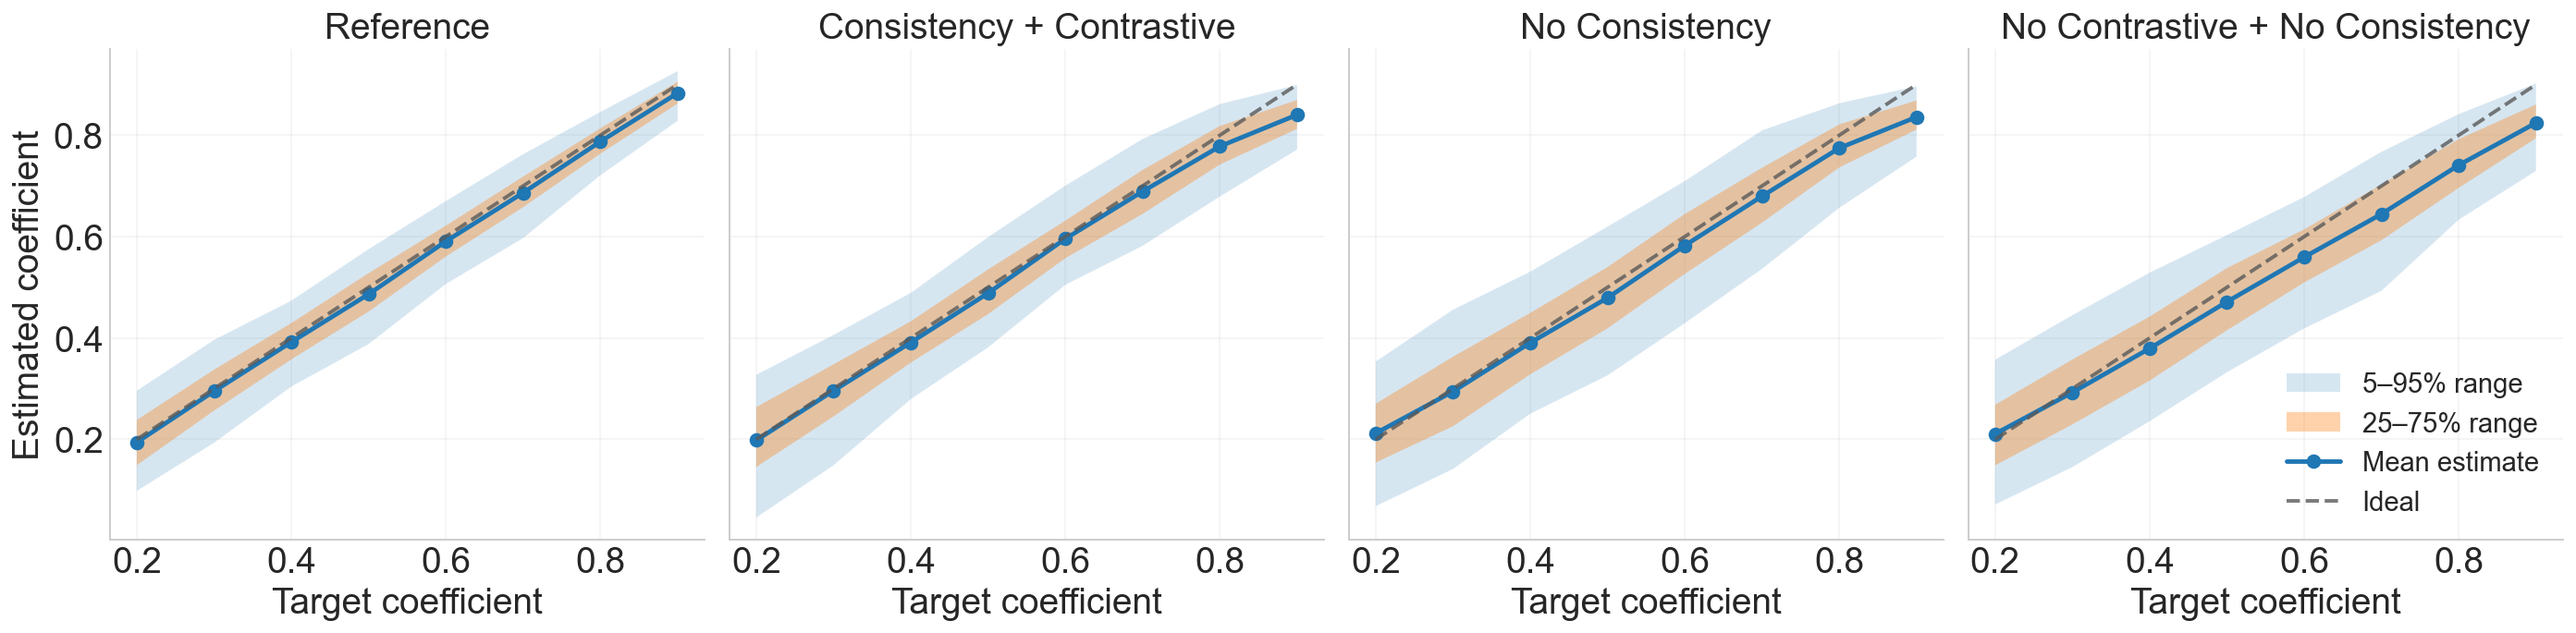

In [9]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)

cmap = plt.cm.coolwarm
norm = plt.Normalize(vmin=min(coeffs), vmax=max(coeffs))

panel_keys = [
    ("reference_coeffs", "Reference"),
    ("consistency_coeffs", "Consistency + Contrastive"),
    ("no_consistency_coeffs", "No Consistency"),
    ("no_contrastive_coeffs", "No Contrastive + No Consistency"),
]

coeffs_arr = np.asarray(coeffs)
xline = np.linspace(coeffs_arr.min(), coeffs_arr.max(), 200)

def _make_subplot(ax, key, title):
    means = []
    q05s, q25s, q75s, q95s = [], [], [], []

    for coeff in coeffs_arr:
        vals = np.asarray(results_dict[coeff][key]).squeeze()

        means.append(vals.mean())
        q05s.append(np.quantile(vals, 0.05))
        q25s.append(np.quantile(vals, 0.25))
        q75s.append(np.quantile(vals, 0.75))
        q95s.append(np.quantile(vals, 0.95))

    means = np.asarray(means)
    q05s = np.asarray(q05s)
    q25s = np.asarray(q25s)
    q75s = np.asarray(q75s)
    q95s = np.asarray(q95s)

    # wide uncertainty band: 5% to 95%
    ax.fill_between(
        coeffs_arr,
        q05s,
        q95s,
        alpha=0.18,
        label="5–95% range",
    )

    # tighter uncertainty band: 25% to 75%
    ax.fill_between(
        coeffs_arr,
        q25s,
        q75s,
        alpha=0.35,
        label="25–75% range",
    )

    # mean estimate
    ax.plot(
        coeffs_arr,
        means,
        marker="o",
        linewidth=2.5,
        markersize=7,
        label="Mean estimate",
    )

    # target = estimate line
    ax.plot(
        xline,
        xline,
        color="0.35",
        linestyle="--",
        linewidth=2,
        alpha=0.8,
        label="Ideal",
    )

    ax.set_title(title, fontsize=20)
    ax.set_xlabel("Target coefficient", fontsize=20)

    # tick font sizes
    ax.tick_params(axis="both", labelsize=20)

    ax.grid(alpha=0.25)

for ax, (key, title) in zip(axes, panel_keys):
    _make_subplot(ax, key, title)

axes[0].set_ylabel("Estimated coefficient", fontsize=20)

axes[-1].legend(
    frameon=False,
    fontsize=16,
    loc="best",
)

plt.tight_layout()

plt.savefig(
    "coefficients_comparison.png",
    dpi=500,
    bbox_inches="tight",
)

plt.show()